In [5]:
import os
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")


import mkssins
from mkssins import *
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import matplotlib as mpl
mpl.rcParams['font.size'] = 16
mpl.rcParams['figure.facecolor'] = 'none'

In [6]:
import os
import pickle
    
folder_path = 'ssins_bdist/bd_dist/'  # Replace with your folder path
data_bdist = {}
fname = []

for filename in os.listdir(folder_path):
      if filename.endswith('_h_rfi_bdist.pickle') or filename.endswith('_h_rfi_bdist.pkl'):
        #print(filename)
        file_prefix = filename.split('_')[0] 
        file_path = os.path.join(folder_path, filename)
        with open(file_path, 'rb') as file:
            data_bdist[file_prefix] = np.load(file, allow_pickle=True)
            fname.append(file_prefix)
        
print(f"Loaded {len(data_bdist)} pickle files.")

Loaded 25 pickle files.


In [212]:
data_bdist


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


{'1637354605': {'m002': {'cd_rfi': array([0, 0, 0, ..., 0, 0, 0]),
   'amp_rfi': array([0.00000000e+00, 3.00300300e+02, 6.00600601e+02, ...,
          5.99584048e+05, 5.99791988e+05, 6.00000000e+05]),
   'cd_rfi_ssins': array([0, 0, 0, ..., 0, 0, 0]),
   'amp_rfi_ssins': array([0.00000000e+00, 3.00300300e+02, 6.00600601e+02, ...,
          5.99584048e+05, 5.99791988e+05, 6.00000000e+05]),
   'nd_norfi': array([0, 0, 0, ..., 0, 0, 0]),
   'amp_norfi': array([0.00000000e+00, 3.00300300e+02, 6.00600601e+02, ...,
          5.99584048e+05, 5.99791988e+05, 6.00000000e+05]),
   'cd_norfi_ssins': array([0, 0, 0, ..., 0, 0, 0]),
   'amp_norfi_ssins': array([0.00000000e+00, 3.00300300e+02, 6.00600601e+02, ...,
          5.99584048e+05, 5.99791988e+05, 6.00000000e+05]),
   'cd_data': array([0, 0, 0, ..., 0, 0, 0]),
   'amp_data': array([0.00000000e+00, 3.00300300e+02, 6.00600601e+02, ...,
          5.99584048e+05, 5.99791988e+05, 6.00000000e+05])},
  'm004': {'cd_rfi': array([0, 0, 0, ..., 0, 0, 

In [210]:
import numpy as np
from scipy.optimize import curve_fit

def power_law(x, factor, exponent):
    return factor * x ** exponent

def linear_law(x, c, m):
    return m * x + c

def power_fit(amp_rfi, cd_rfi):
    # Apply amplitude range mask
    index = np.where((amp_rfi >= 7500) & (amp_rfi <= 100000))
    amp_slope = np.array(amp_rfi[index])
    cd_slope = np.array(cd_rfi[index])

    # Ensure both arrays are positive and finite
    valid = (amp_slope > 0) & (cd_slope > 0) & \
            np.isfinite(amp_slope) & np.isfinite(cd_slope)

    # Apply the valid mask
    x_data = np.log(amp_slope[valid])
    y_data = np.log(cd_slope[valid])

    # Check if you have enough points to fit
    if len(x_data) < 2:
        raise ValueError("Not enough valid data points for fitting.")

    # Fit log-log data to linear model
    params, covariance = curve_fit(linear_law, x_data, y_data)
    fac_fit, exp_fit = np.exp(params[0]), params[1]

    return fac_fit, exp_fit


In [193]:
def bd(data_dict):
    results = {}
    for fname, ant_rfi in data_dict.items():
        obs_cd_katcali = []
        obs_amp_katcali = []
        obs_cd_ssins = []
        obs_amp_ssins = []
        obs_cd_data = []
        obs_amp_data = []

        for ant, value in ant_rfi.items():
            obs_cd_katcali.append(value['cd_rfi'])
            obs_amp_katcali.append(value['amp_rfi'])
            obs_cd_ssins.append(value['cd_rfi_ssins'])
            obs_amp_ssins.append(value['amp_rfi_ssins'])
            obs_cd_data.append(value['cd_data'])
            obs_amp_data.append(value['amp_data'])
                
        cd_rfi_katcali = np.nansum(np.array(obs_cd_katcali), axis=0)
        amp_rfi_katcali = np.nansum(np.array(obs_amp_katcali), axis=0)
        cd_rfi_ssins = np.nansum(np.array(obs_cd_ssins), axis=0)
        amp_rfi_ssins = np.nansum(np.array(obs_amp_ssins), axis=0)
        data_amp = np.nansum(np.array(obs_amp_data), axis=0)
        data_cd = np.nansum(np.array(obs_cd_data), axis=0)
        
        
        results[fname] = {
            'cd_rfi_katcali': cd_rfi_katcali,
            'amp_rfi_katcali': amp_rfi_katcali,
            'cd_rfi_ssins': cd_rfi_ssins,
            'amp_rfi_ssins': amp_rfi_ssins,
            'data_cd': data_cd,
            'data_amp': data_amp
        }

    return results


In [194]:
bdist_round_1 = bd(data_bdist)

In [201]:
bdist_round_1.keys()

dict_keys(['1637354605', '1637346562', '1631990463', '1638386189', '1637691677', '1637699408', '1631982988', '1638301944', '1632760885', '1638130295', '1632184922', '1631559762', '1639157507', '1631667564', '1631387336', '1631810671', '1634402485', '1631818149', '1638639082', '1631732038', '1638294319', '1634252028', '1630519596', '1632077222', '1632069690'])

Skipping 1637354605 due to fit error: Not enough valid data points for fitting.


<Figure size 1200x600 with 0 Axes>

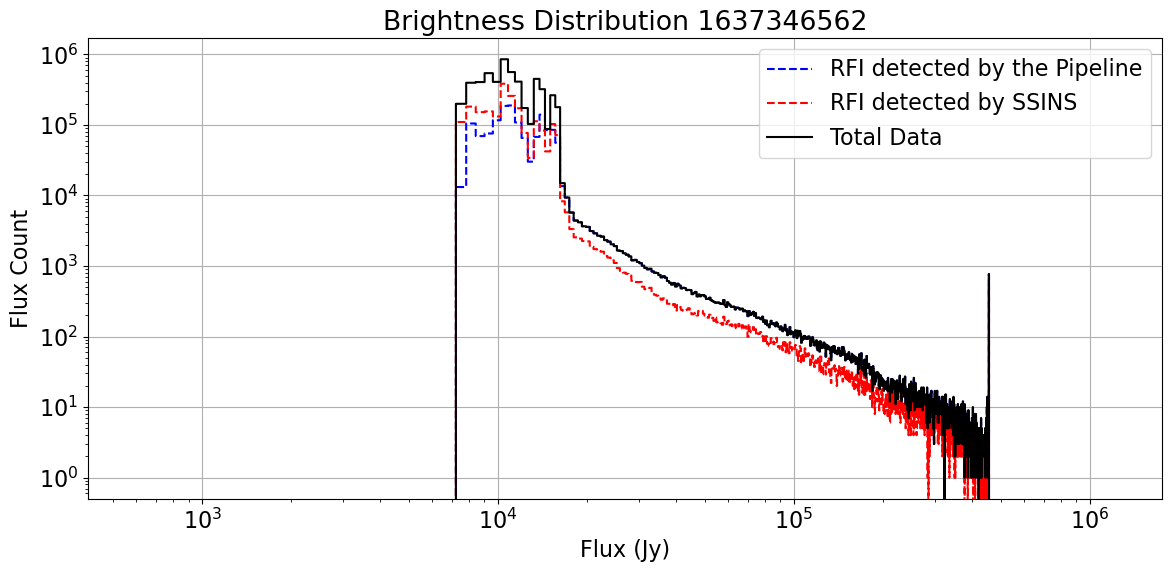

Skipping 1631990463 due to fit error: Not enough valid data points for fitting.
Skipping 1638386189 due to fit error: Not enough valid data points for fitting.
Skipping 1637691677 due to fit error: Not enough valid data points for fitting.
Skipping 1637699408 due to fit error: Not enough valid data points for fitting.
Skipping 1631982988 due to fit error: Not enough valid data points for fitting.
Skipping 1638301944 due to fit error: Not enough valid data points for fitting.
Skipping 1632760885 due to fit error: Not enough valid data points for fitting.


<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

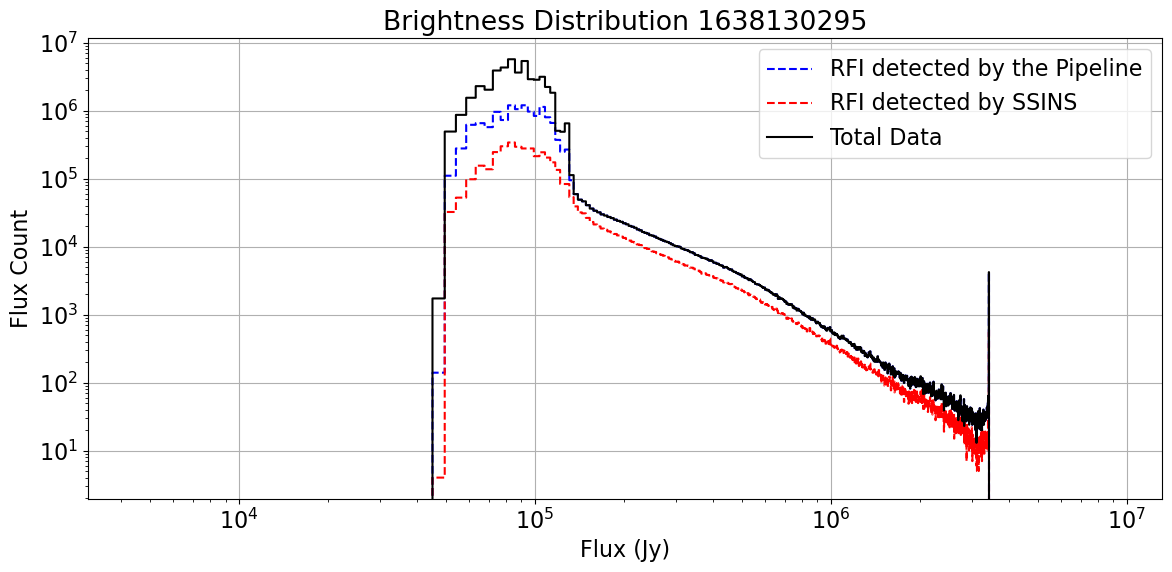

Skipping 1632184922 due to fit error: Not enough valid data points for fitting.
Skipping 1631559762 due to fit error: Not enough valid data points for fitting.


<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

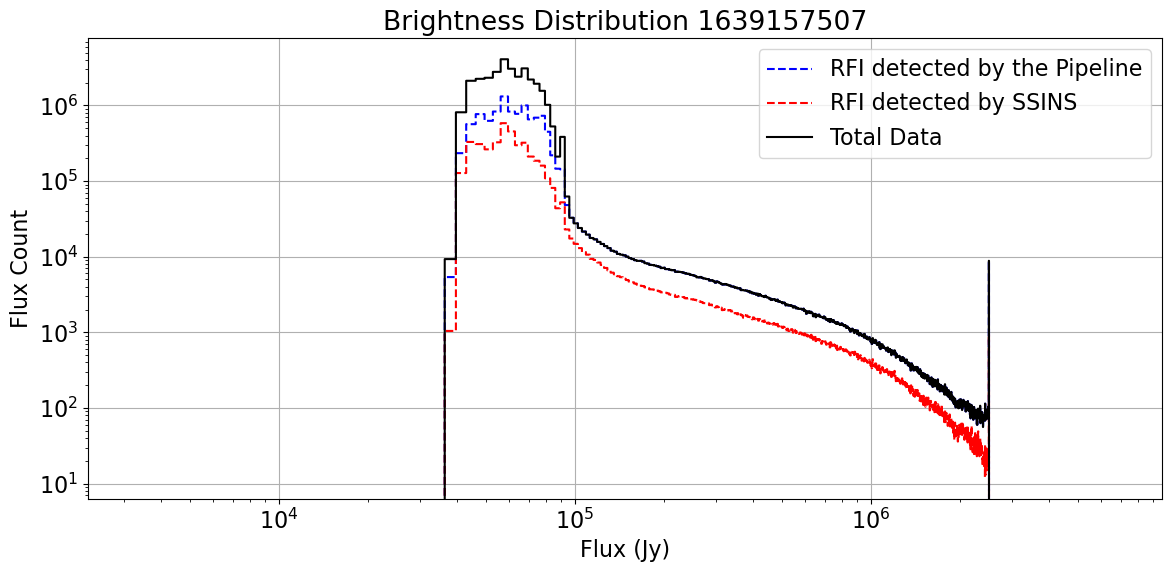

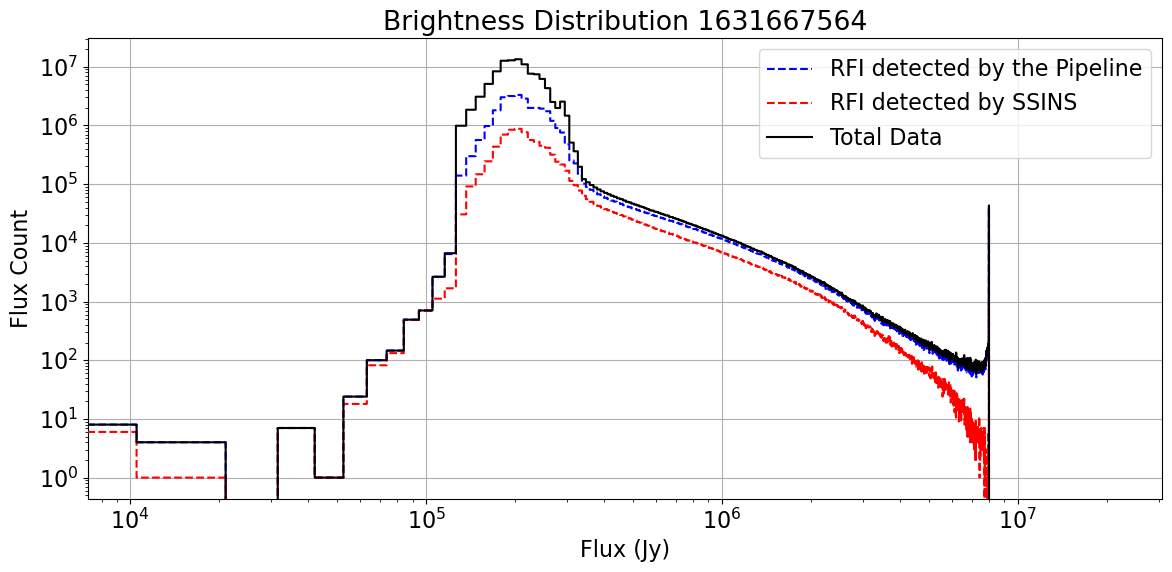

Skipping 1631387336 due to fit error: Not enough valid data points for fitting.
Skipping 1631810671 due to fit error: Not enough valid data points for fitting.
Skipping 1634402485 due to fit error: Not enough valid data points for fitting.
Skipping 1631818149 due to fit error: Not enough valid data points for fitting.


<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

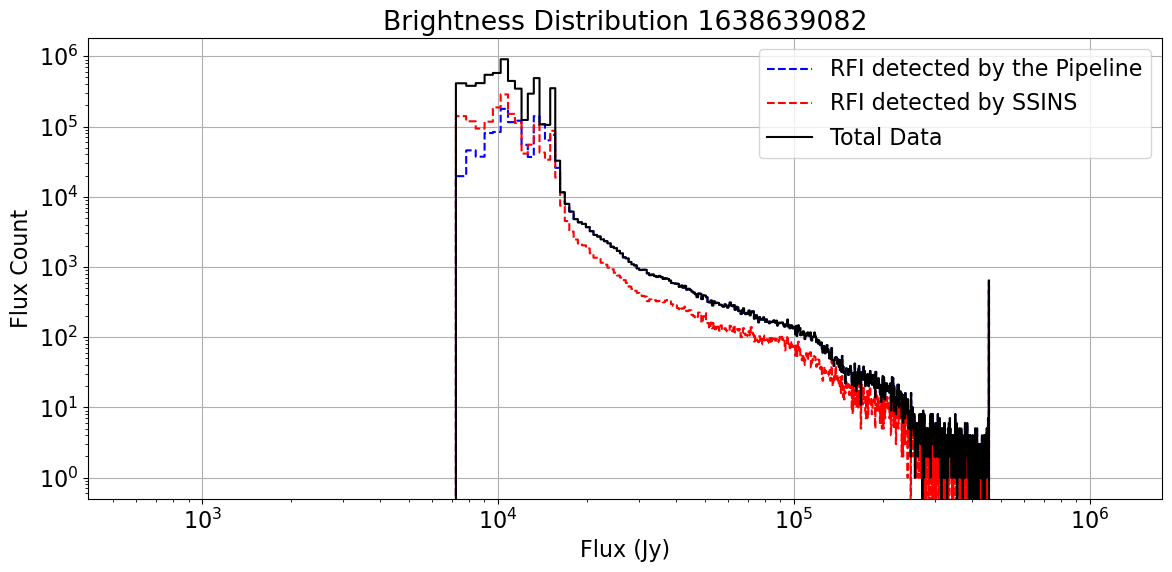

Skipping 1631732038 due to fit error: Not enough valid data points for fitting.


<Figure size 1200x600 with 0 Axes>

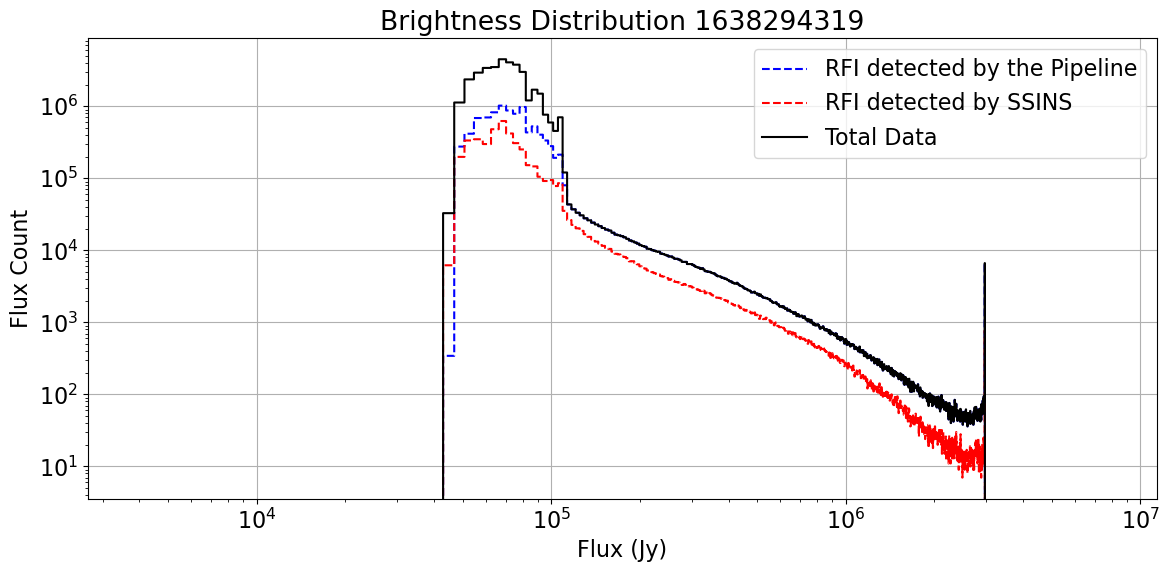

Skipping 1634252028 due to fit error: Not enough valid data points for fitting.
Skipping 1630519596 due to fit error: Not enough valid data points for fitting.
Skipping 1632077222 due to fit error: Not enough valid data points for fitting.
Skipping 1632069690 due to fit error: Not enough valid data points for fitting.


<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [211]:

for fname, data in bdist_round_1.items():
    plt.figure(figsize=(12, 6))
    
    try:
        factor, fit = power_fit(data['amp_rfi_katcali'][:-1], data['cd_rfi_katcali'])
        factor_ssins, fit_ssins = power_fit(data['amp_rfi_ssins'][:-1], data['cd_rfi_ssins'])
    except ValueError as e:
        print(f"Skipping {fname} due to fit error: {e}")
        continue
    
    # Plot with the format you specified
    plt.step(data['amp_rfi_katcali'][:-1], data['cd_rfi_katcali'], label='RFI detected by the Pipeline', linestyle='--', color='blue', zorder=5)
    ax.plot(data['amp_rfi_katcali'][:-1], power_law(data['amp_rfi_katcali'][:-1], factor, fit), color='green', label=f'Fitted Power Law : {fit}')
    plt.step(data['amp_rfi_ssins'][:-1], data['cd_rfi_ssins'], label='RFI detected by SSINS', linestyle='--', color='r', zorder=5)
    ax.plot(data['amp_rfi_ssins'][:-1], power_law(data['amp_rfi_ssins'][:-1], factor, fit), color='green', label=f'Fitted Power Law : {fit}')
    plt.step(data['data_amp'][:-1], data['data_cd'], label='Total Data', linestyle='-', color='black', zorder=5)
    plt.xlabel('Flux (Jy)')
    plt.ylabel('Flux Count')
    plt.xscale('log')
    plt.yscale('log')
    plt.title(f'Brightness Distribution {fname}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


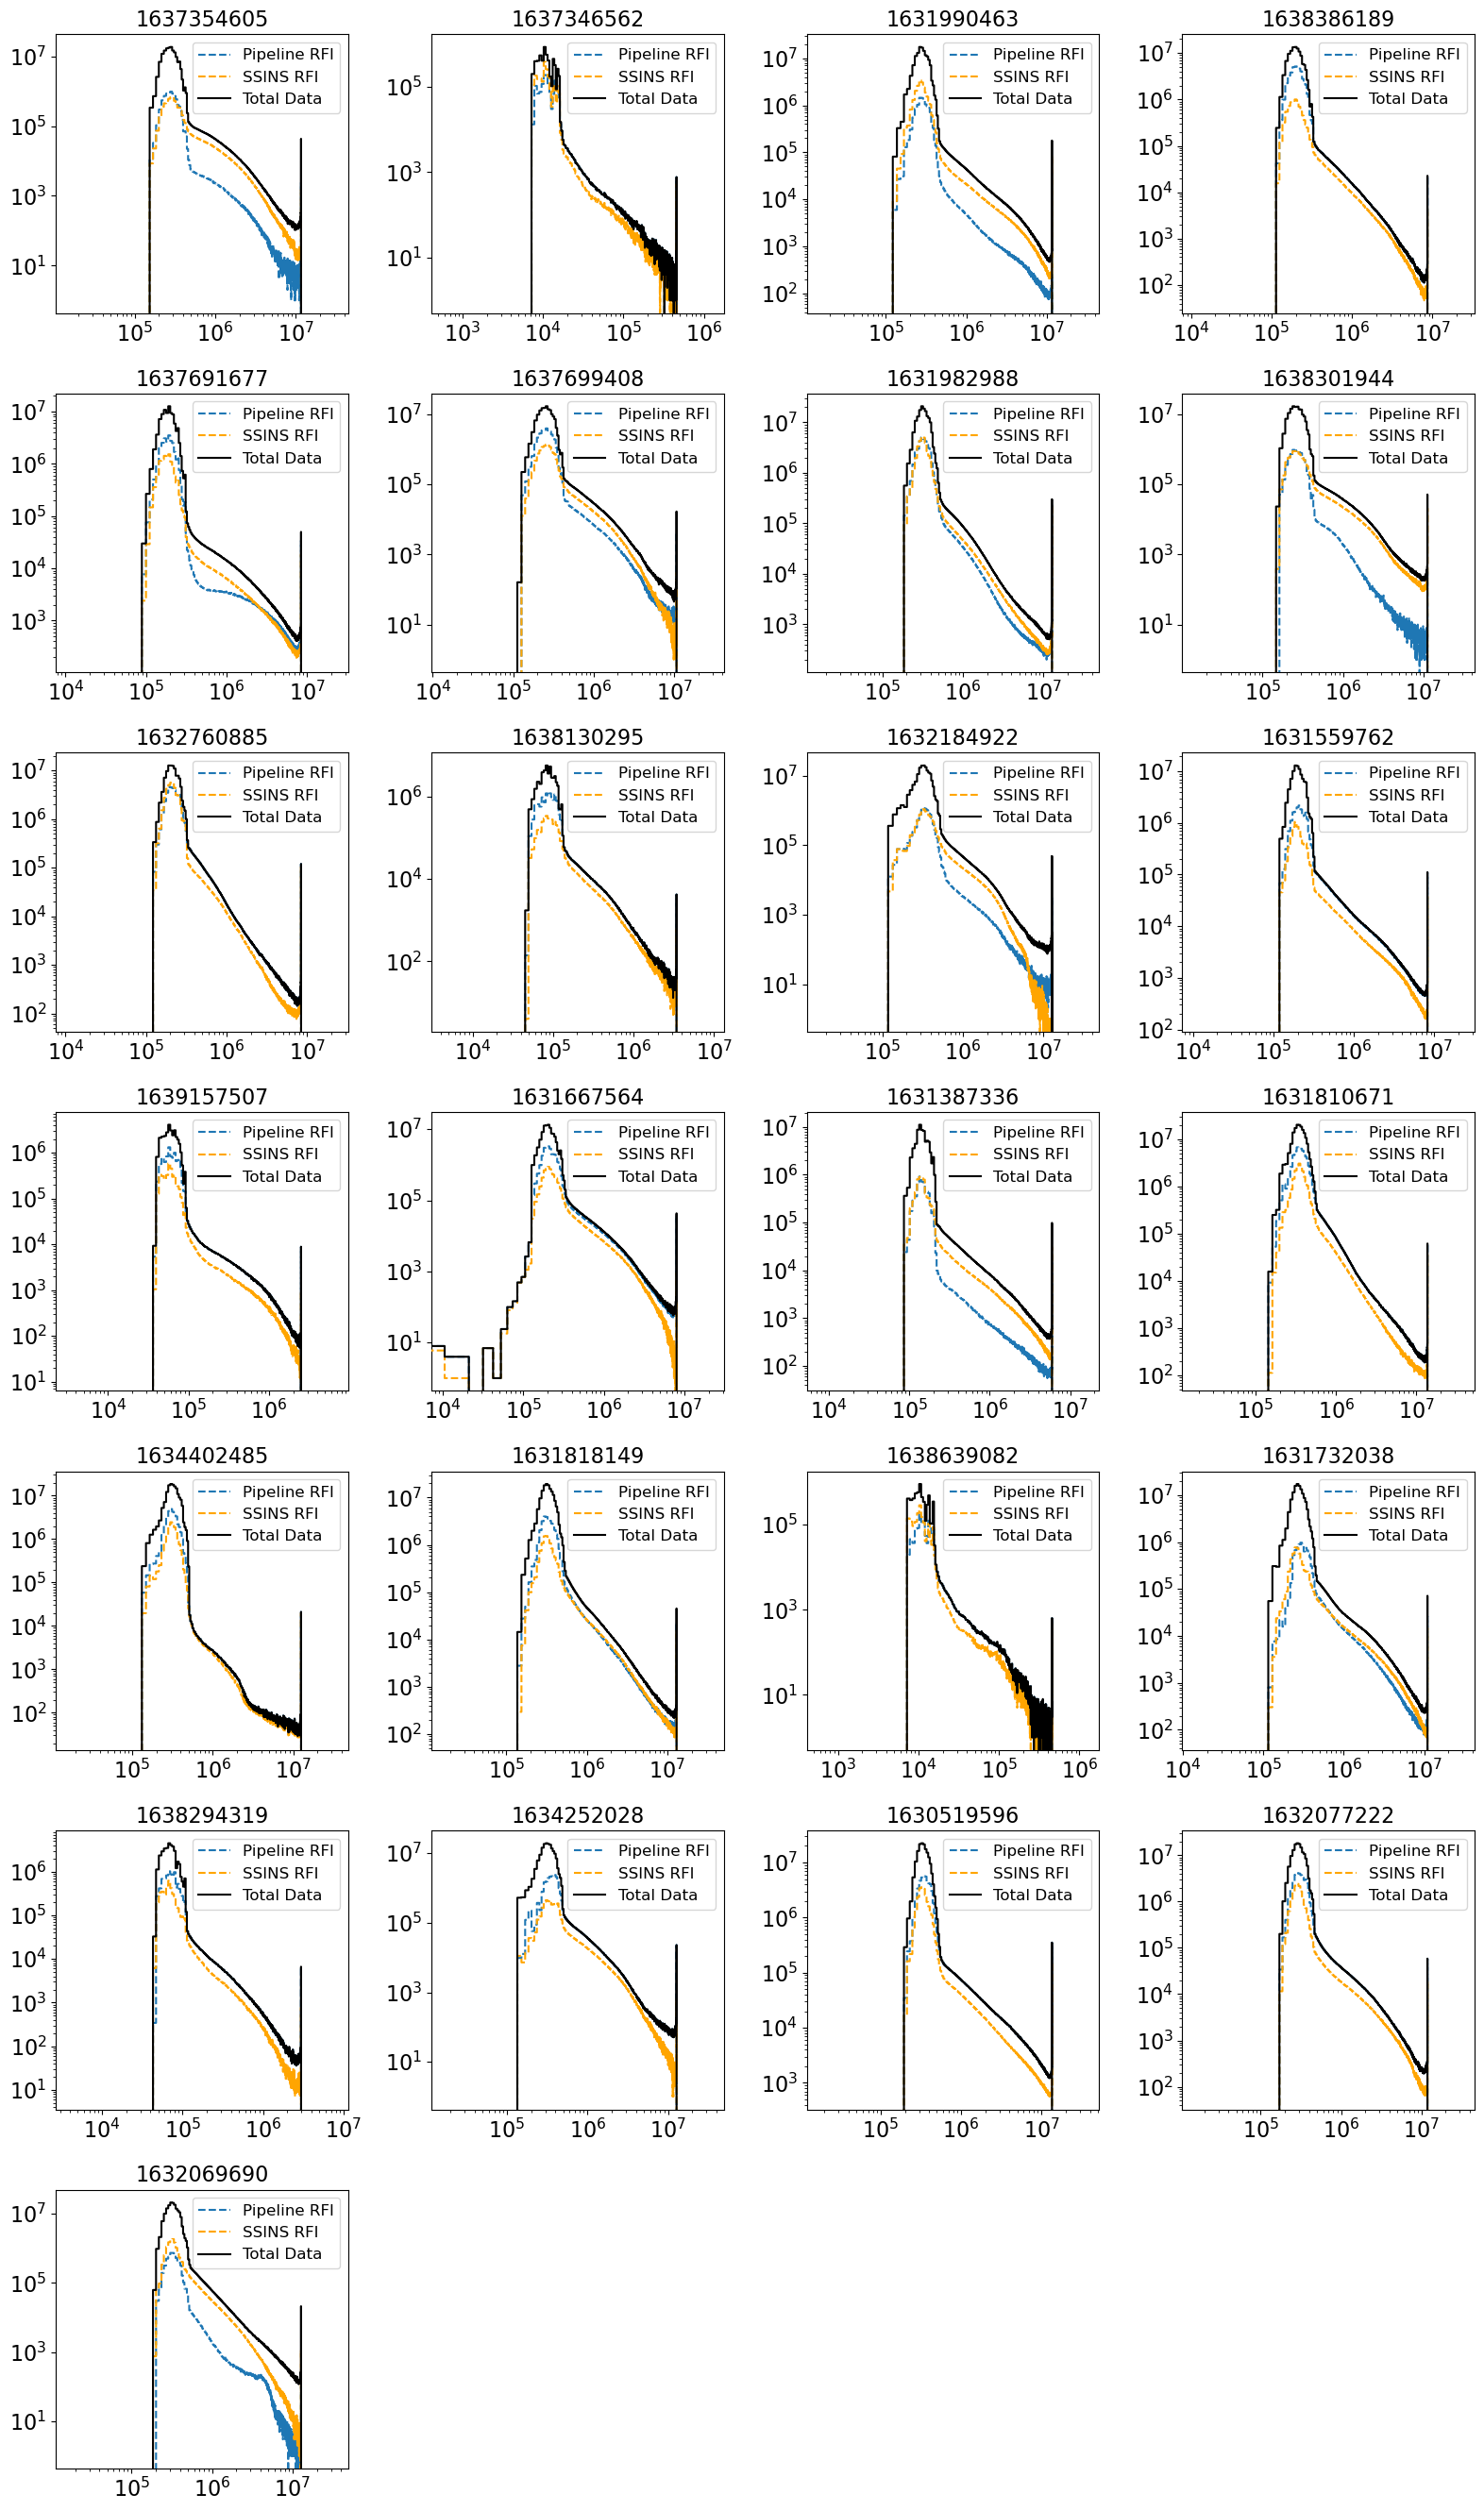

In [59]:
# plot the graphs as a wall waterfall
import matplotlib.pyplot as plt
import math

# Parameters for grid layout
n_files = len(bdist_round_1)
n_cols = 4  # Change to control how wide the wall is
n_rows = math.ceil(n_files / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = axes.flatten()  # To index axes easily

for idx, (fname, data) in enumerate(bdist_round_1.items()):
    ax = axes[idx]
    
    # Plot using the axis
    ax.step(data['amp_rfi_katcali'][:-1], data['cd_rfi_katcali'],
            label='Pipeline RFI', linestyle='--', zorder=5)

    ax.step(data['amp_rfi_ssins'][:-1], data['cd_rfi_ssins'],
            label='SSINS RFI', linestyle='--', color='orange', zorder=5)

    ax.step(data['data_amp'][:-1], data['data_cd'],
             label='Total Data',
             linestyle='-', color='black', zorder=5)



    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(fname, fontsize=16)
    #ax.grid(True)
    ax.legend(fontsize=12, loc = 'upper right')
    
'''
    if idx == 0:
        ax.legend(fontsize=8)
    else:
        ax.legend().remove()
'''

# Hide empty subplots
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

#fig.suptitle('Brightness Distribution Wall', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
# Plot the power-law of these distributions

In [88]:
import os
import pickle
    
folder_path = 'ssins_bdist/pipeline_slope'  # Replace with your folder path
data_slope_katcali = {}
fname = []

for filename in os.listdir(folder_path):
      if filename.endswith('_h_pipeline_slope.pickle') or filename.endswith('_h_pipeline_slope.pkl'):
        #print(filename)
        file_prefix = filename.split('_')[0] 
        file_path = os.path.join(folder_path, filename)
        with open(file_path, 'rb') as file:
            data_slope_katcali[file_prefix] = np.load(file, allow_pickle=True)
            fname.append(file_prefix)
        
print(f"Loaded {len(data_slope_katcali)} pickle files.")

Loaded 25 pickle files.


In [87]:
import os
import pickle
    
folder_path = 'ssins_bdist/ssins_slope'  # Replace with your folder path
data_slope_ssins = {}
fname = []

for filename in os.listdir(folder_path):
      if filename.endswith('_h_ssins_slope.pickle') or filename.endswith('_h_ssins_slope.pkl'):
        #print(filename)
        file_prefix = filename.split('_')[0] 
        file_path = os.path.join(folder_path, filename)
        with open(file_path, 'rb') as file:
            data_slope_ssins[file_prefix] = np.load(file, allow_pickle=True)
            fname.append(file_prefix)
        
print(f"Loaded {len(data_slope_ssins)} pickle files.")

Loaded 25 pickle files.


In [44]:
data_slope_katcali['1631559762']['m000'].keys()

dict_keys(['factor', 'exponent', 'x_data', 'y_data'])

In [160]:
for f, ant_slope in data_slope_katcali.items():
    print(ant_slope)
    print(f)

{'m000': {'factor': np.float64(526458954.0534431), 'exponent': np.float64(-1.3409365895865866), 'x_data': array([  8708.70870871,   9009.00900901,   9309.30930931,   9609.60960961,
         9909.90990991,  10210.21021021,  10510.51051051,  10810.81081081,
        11111.11111111,  11411.41141141,  11711.71171171,  12012.01201201,
        12312.31231231,  12612.61261261,  12912.91291291,  13213.21321321,
        13513.51351351,  13813.81381381,  14114.11411411,  14414.41441441,
        14714.71471471,  15015.01501502,  15315.31531532,  15615.61561562,
        15915.91591592,  16216.21621622,  16516.51651652,  16816.81681682,
        17117.11711712,  17417.41741742,  17717.71771772,  18018.01801802,
        18318.31831832,  18618.61861862,  18918.91891892,  19219.21921922,
        19519.51951952,  19819.81981982,  20120.12012012,  20420.42042042,
        20720.72072072,  21021.02102102,  21321.32132132,  21621.62162162,
        21921.92192192,  22222.22222222,  22522.52252252,  22822.8228

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [163]:
from collections import defaultdict
import numpy as np

# Initialize the accumulator dictionary
sum_dict = defaultdict(float)

# Loop over antennas
for ant, data in data_slope_katcali['1631559762'].items():
    for key in ['factor', 'exponent', 'x_data', 'y_data']:
        value = data.get(key)
        if isinstance(value, (int, float)):
            sum_dict[key] += value
        elif isinstance(value, list) or isinstance(value, np.ndarray):
            sum_dict[key] += np.sum(value, axis=0)
        else:
            raise TypeError(f"Unsupported type for key '{key}': {type(value)}")

# Convert back to regular dict if you want
sum_result = dict(sum_dict)


In [164]:
sum_result

{'factor': np.float64(1193597783143978.2),
 'exponent': np.float64(-59.20745928430857),
 'x_data': np.float64(580232732.7327329),
 'y_data': np.float64(4417124.0)}

In [166]:
from collections import defaultdict
import numpy as np

# Temporary storage for accumulating values
accumulator = defaultdict(list)

# Collect all values per key
for ant_data in data_slope_katcali['1631559762'].values():
    for key in ['factor', 'exponent', 'x_data', 'y_data']:
        value = ant_data.get(key)
        accumulator[key].append(np.array(value))  # convert scalars to arrays too

# Compute averages
average_result = {}
for key, values in accumulator.items():
    stacked = np.stack(values)
    average_result[key] = np.mean(stacked, axis=0)

# average_result now contains mean of each key across antennas


In [167]:
average_result

{'factor': np.float64(34102793804113.664),
 'exponent': np.float64(-1.6916416938373877),
 'x_data': array([  8708.70870871,   9009.00900901,   9309.30930931,   9609.60960961,
          9909.90990991,  10210.21021021,  10510.51051051,  10810.81081081,
         11111.11111111,  11411.41141141,  11711.71171171,  12012.01201201,
         12312.31231231,  12612.61261261,  12912.91291291,  13213.21321321,
         13513.51351351,  13813.81381381,  14114.11411411,  14414.41441441,
         14714.71471471,  15015.01501502,  15315.31531532,  15615.61561562,
         15915.91591592,  16216.21621622,  16516.51651652,  16816.81681682,
         17117.11711712,  17417.41741742,  17717.71771772,  18018.01801802,
         18318.31831832,  18618.61861862,  18918.91891892,  19219.21921922,
         19519.51951952,  19819.81981982,  20120.12012012,  20420.42042042,
         20720.72072072,  21021.02102102,  21321.32132132,  21621.62162162,
         21921.92192192,  22222.22222222,  22522.52252252,  22822

In [168]:
average_result.keys()

dict_keys(['factor', 'exponent', 'x_data', 'y_data'])